In [ ]:
# Fruit Classification Using Convolutional Neural Network 🍎🍌🍇🥭🍓

## Overview

This project implements a Convolutional Neural Network (CNN) to classify fruit images into five categories:

- Apple
- Banana
- Grape
- Mango
- Strawberry

The workflow includes dataset preparation, image preprocessing, data augmentation, CNN model development, training, evaluation, and fruit image prediction.

## Objective

The objective of this project is to develop an image classification model that can recognize different types of fruits based on their visual features.

## Model Overview

The model uses a Convolutional Neural Network with convolutional layers, max pooling, a fully connected layer, dropout, and a softmax output layer.

## Dataset

The dataset contains five fruit classes and is divided into training, validation, and testing sets.

Image size: **128 × 128 pixels**

---

In [ ]:
# STEP 1 : MOUNT GOOGLE DRIVE
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# STEP 2 : IMPORT LIBRARY
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array
)

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

In [ ]:
# STEP 3 : CEK PATH DATASET


train_path = "/content/drive/MyDrive/Praktikum AI/tubes praktikum ai/dataset_FruitsClassification/train"
valid_path = "/content/drive/MyDrive/Praktikum AI/tubes praktikum ai/dataset_FruitsClassification/valid"
test_path = "/content/drive/MyDrive/Praktikum AI/tubes praktikum ai/dataset_FruitsClassification/test"
print(os.listdir(train_path))

['Apple', 'Strawberry', 'Grape', 'Mango', 'Banana']


In [ ]:
## 1. Data Preparation

The dataset paths are defined for the training, validation, and testing data.

The images are resized to 128 × 128 pixels before being passed to the CNN model.

In [ ]:
# STEP 4 : PREPROCESSING & DATA AUGMENTATION

img_size = 128
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
# STEP 5 : LOAD DATA TRAINING

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 9715 images belonging to 5 classes.


In [ ]:
# STEP 6 : LOAD DATA VALIDATION

valid_data = test_datagen.flow_from_directory(
    valid_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 200 images belonging to 5 classes.


In [ ]:
# STEP 7 : LOAD DATA TESTING

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 100 images belonging to 5 classes.


In [ ]:
# STEP 8 : CEK NAMA KELAS

print(train_data.class_indices)

{'Apple': 0, 'Banana': 1, 'Grape': 2, 'Mango': 3, 'Strawberry': 4}


In [ ]:
## 2. CNN Model Architecture

A Convolutional Neural Network (CNN) is used because the project involves image classification.

The model consists of:

- Convolutional layers for extracting visual features
- MaxPooling layers for reducing spatial dimensions
- Flatten layer for converting feature maps into a vector
- Dense layer for classification
- Dropout layer to help reduce overfitting
- Softmax output layer for predicting the five fruit classes

In [ ]:
# STEP 9 : BANGUN MODEL CNN

model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(img_size, img_size, 3)
    ),

    MaxPooling2D(2,2),
    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Flatten(),
    Dense(
        256, #awalnya128
        activation='relu'
    ),

    Dropout(0.5),
    Dense(
        train_data.num_classes,
        activation='softmax'
    )

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# STEP 10 : COMPILE MODEL

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(
        learning_rate=0.0005
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# STEP 11 : TAMPILKAN ARSITEKTUR MODEL

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    14,745,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,766,533 (56.33 MB)

 Trainable params: 14,766,533 (56.33 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# STEP 12 : SETUP EARLY STOPPING

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

In [ ]:
## 3. Model Training

The model is trained using the training dataset and evaluated against the validation dataset during training.

The training configuration uses:

- Optimizer: Adam
- Learning rate: 0.0005
- Maximum epochs: 100
- Batch size: 32
- Early stopping: Enabled

In [ ]:
# STEP 13 : TRAINING MODEL

history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=100,
    callbacks=[early_stop]
)

Epoch 1/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 1927s 6s/step - accuracy: 0.4295 - loss: 1.3705 - val_accuracy: 0.5100 - val_loss: 1.1230
Epoch 2/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 351s 1s/step - accuracy: 0.5221 - loss: 1.1507 - val_accuracy: 0.5500 - val_loss: 1.0873
Epoch 3/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 380s 1s/step - accuracy: 0.5560 - loss: 1.0910 - val_accuracy: 0.6000 - val_loss: 1.0220
Epoch 4/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 348s 1s/step - accuracy: 0.5718 - loss: 1.0492 - val_accuracy: 0.5650 - val_loss: 1.0421
Epoch 5/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 346s 1s/step - accuracy: 0.5916 - loss: 1.0174 - val_accuracy: 0.6100 - val_loss: 0.9569
Epoch 6/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 345s 1s/step - accuracy: 0.6103 - loss: 0.9811 - val_accuracy: 0.6150 - val_loss: 0.9653
Epoch 7/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 346s 1s/step - accuracy: 0.6177 - loss: 0.9679 - val_accuracy: 0.6000 - val_loss: 0.9122
Epoch 8/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 345s 1s/step - accuracy: 0.6330 - loss: 0.9435 -

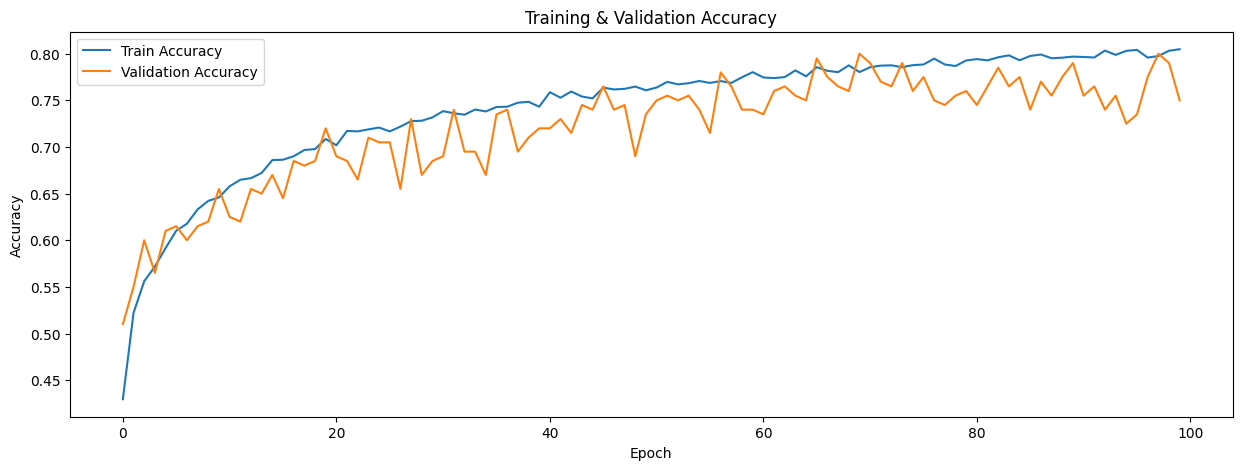

In [ ]:
# STEP 14 : VISUALISASI ACCURACY

plt.figure(figsize=(15,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Training & Validation Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

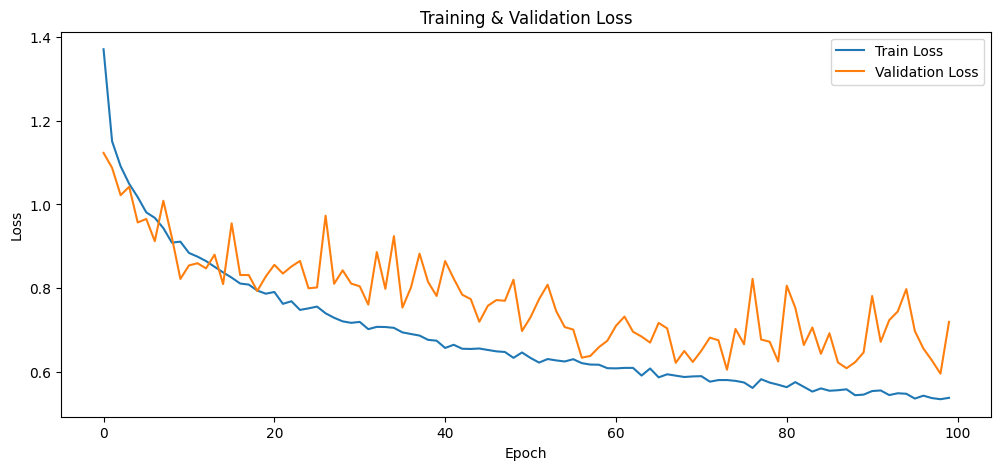

In [ ]:
# STEP 15 : VISUALISASI LOSS

plt.figure(figsize=(12,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Training & Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

In [ ]:
## 4. Model Evaluation

After training, the model is evaluated using the test dataset.

The evaluation includes:

- Test loss
- Test accuracy
- Confusion matrix
- Classification report

In [ ]:
# STEP 16 : EVALUASI MODEL

loss, accuracy = model.evaluate(test_data)

print("Loss :", loss)

print("Accuracy :", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.8200 - loss: 0.6132
Loss : 0.6132134199142456
Accuracy : 0.8199999928474426


In [ ]:
# STEP 17 : PREDIKSI DATA TEST

Y_pred = model.predict(test_data)

y_pred = np.argmax(Y_pred, axis=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step


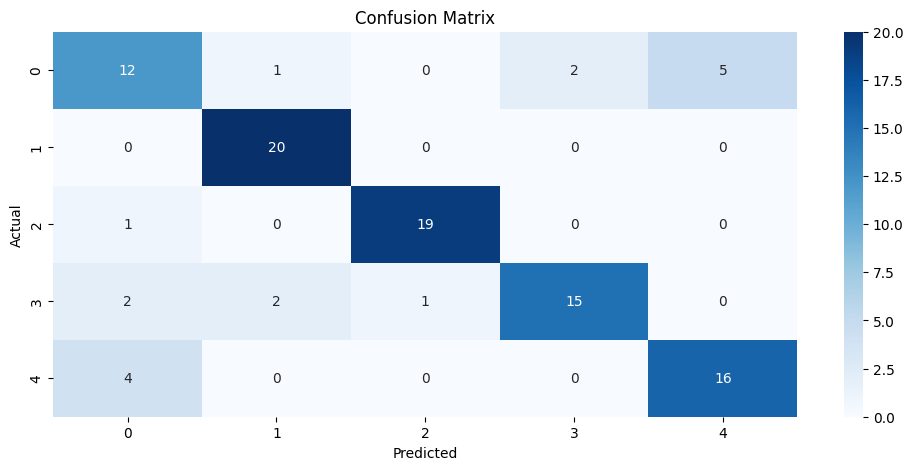

In [ ]:
# STEP 18 : CONFUSION MATRIX

cm = confusion_matrix(
    test_data.classes,
    y_pred
)

plt.figure(figsize=(12,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

In [ ]:
# STEP 19 : CLASSIFICATION REPORT

print(
    classification_report(
        test_data.classes,
        y_pred,
        target_names=list(
            test_data.class_indices.keys()
        )
    )
)

              precision    recall  f1-score   support

       Apple       0.63      0.60      0.62        20
      Banana       0.87      1.00      0.93        20
       Grape       0.95      0.95      0.95        20
       Mango       0.88      0.75      0.81        20
  Strawberry       0.76      0.80      0.78        20

    accuracy                           0.82       100
   macro avg       0.82      0.82      0.82       100
weighted avg       0.82      0.82      0.82       100



In [ ]:
# STEP 20 : SIMPAN MODEL

model.save(
    "/content/drive/MyDrive/model_cnn_buah.h5"
)

print("Model berhasil disimpan!")

Model berhasil disimpan!


In [ ]:
## 5. Fruit Image Prediction

The trained model can also be used to predict the class of a new fruit image.

The prediction process returns the predicted fruit class along with its confidence score.

In [ ]:
# STEP 21 : UPLOAD GAMBAR UNTUK PREDIKSI

from google.colab import files

uploaded = files.upload()

Saving Apple (233).jpeg to Apple (233).jpeg
Saving Apple (1413).jpeg to Apple (1413).jpeg
Saving Banana (2580).jpeg to Banana (2580).jpeg
Saving Banana (3362).jpeg to Banana (3362).jpeg
Saving Grape (387).jpeg to Grape (387).jpeg
Saving Grape (1470).jpeg to Grape (1470).jpeg
Saving Mango (900).jpeg to Mango (900).jpeg
Saving Mango (1477).jpeg to Mango (1477).jpeg
Saving Strawberry (792).jpeg to Strawberry (792).jpeg
Saving Strawberry (1590).jpeg to Strawberry (1590).jpeg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


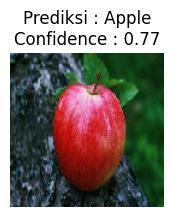

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


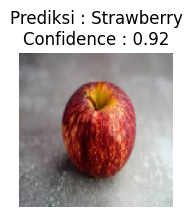

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step


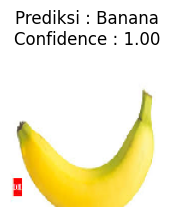

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step


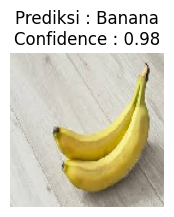

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step


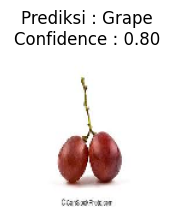

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


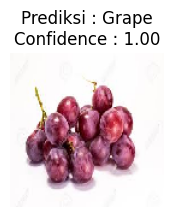

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step


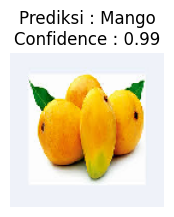

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


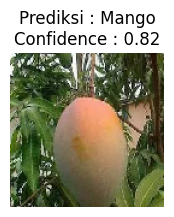

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


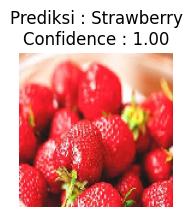

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


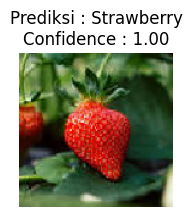

In [ ]:
# STEP 22 : PREDIKSI GAMBAR BUAH

class_names = list(
    train_data.class_indices.keys()
)

for filename in uploaded.keys():

    img = load_img(
        filename,
        target_size=(img_size, img_size)
    )

    img_array = img_to_array(img)

    img_array = img_array / 255.0

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    prediction = model.predict(
        img_array
    )

    predicted_class = class_names[
        np.argmax(prediction)
    ]

    confidence = np.max(prediction)

    plt.figure(figsize=(2,2))

    plt.imshow(img)

    plt.title(
        f"Prediksi : {predicted_class}\n"
        f"Confidence : {confidence:.2f}"
    )

    plt.axis('off')

    plt.show()

In [ ]:
## 6. Conclusion

This project demonstrates the use of a Convolutional Neural Network for multi-class fruit image classification.

The model is trained to classify five fruit categories: Apple, Banana, Grape, Mango, and Strawberry.

The final model is evaluated using the test dataset, and its performance is analyzed using accuracy, loss, confusion matrix, and classification report.